In [1]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt   
import seaborn as sns

In [2]:
df = pd.read_csv("fetalhealth.csv")

In [ ]:
Exploratory Data Analysis

In [4]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,1


In [5]:
print(df.shape)

(2126, 22)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   int64  
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   int64  
 8   mean_value_of_short_term_variability  

In [7]:
df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [8]:
df.duplicated().sum()

np.int64(13)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(2113, 22)

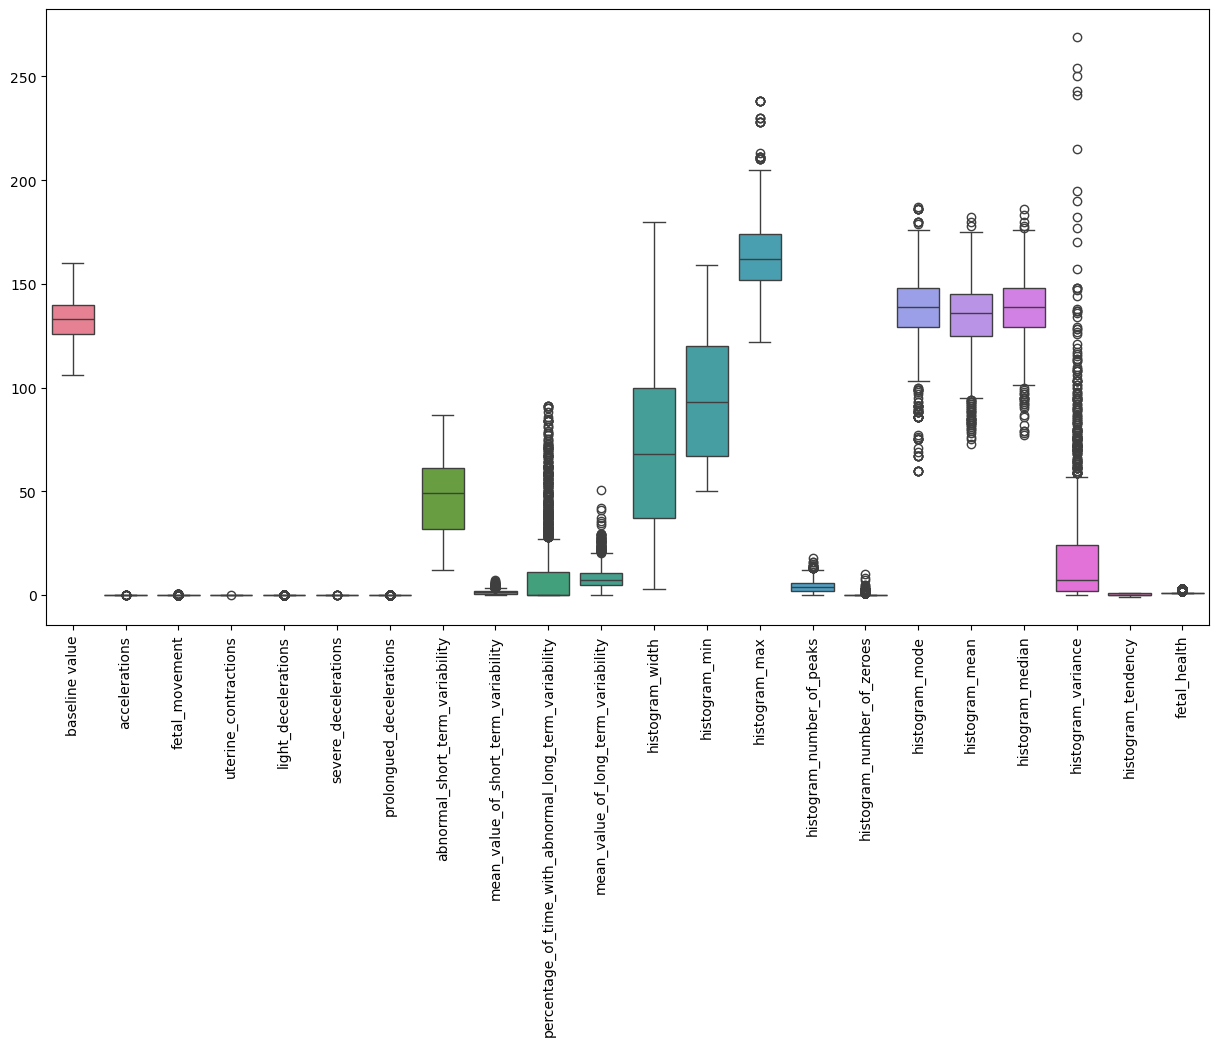

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

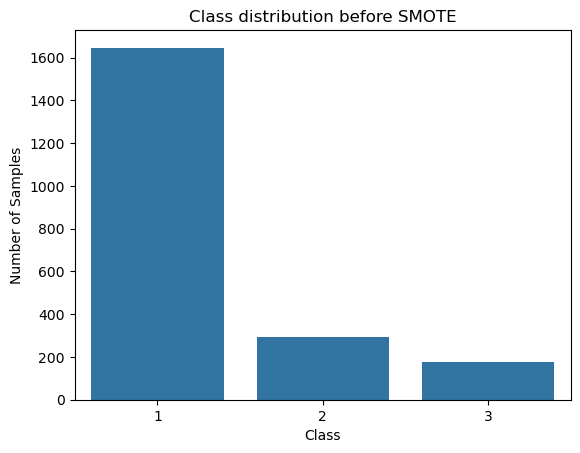

In [13]:
sns.countplot(x='fetal_health', data=df)
plt.title("Class distribution before SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

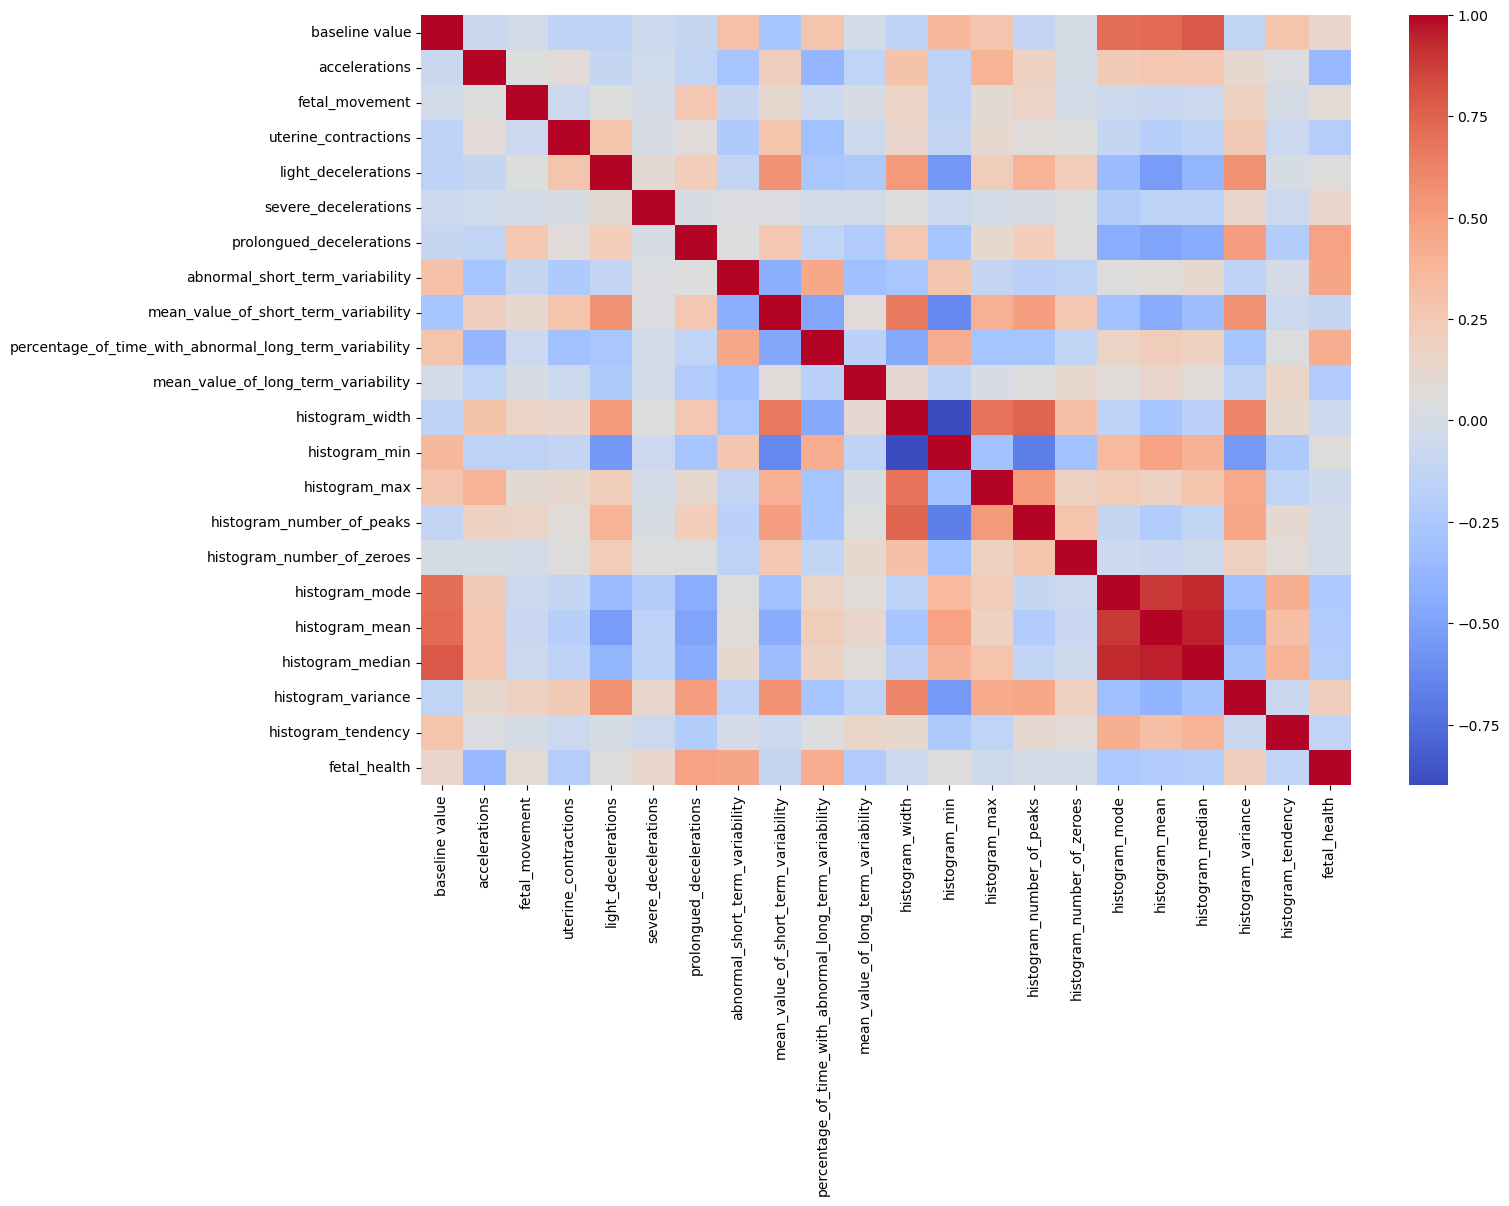

In [14]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),
            cmap='coolwarm')

plt.show()

In [ ]:
Detecting Outliers with Inter Quartile Range

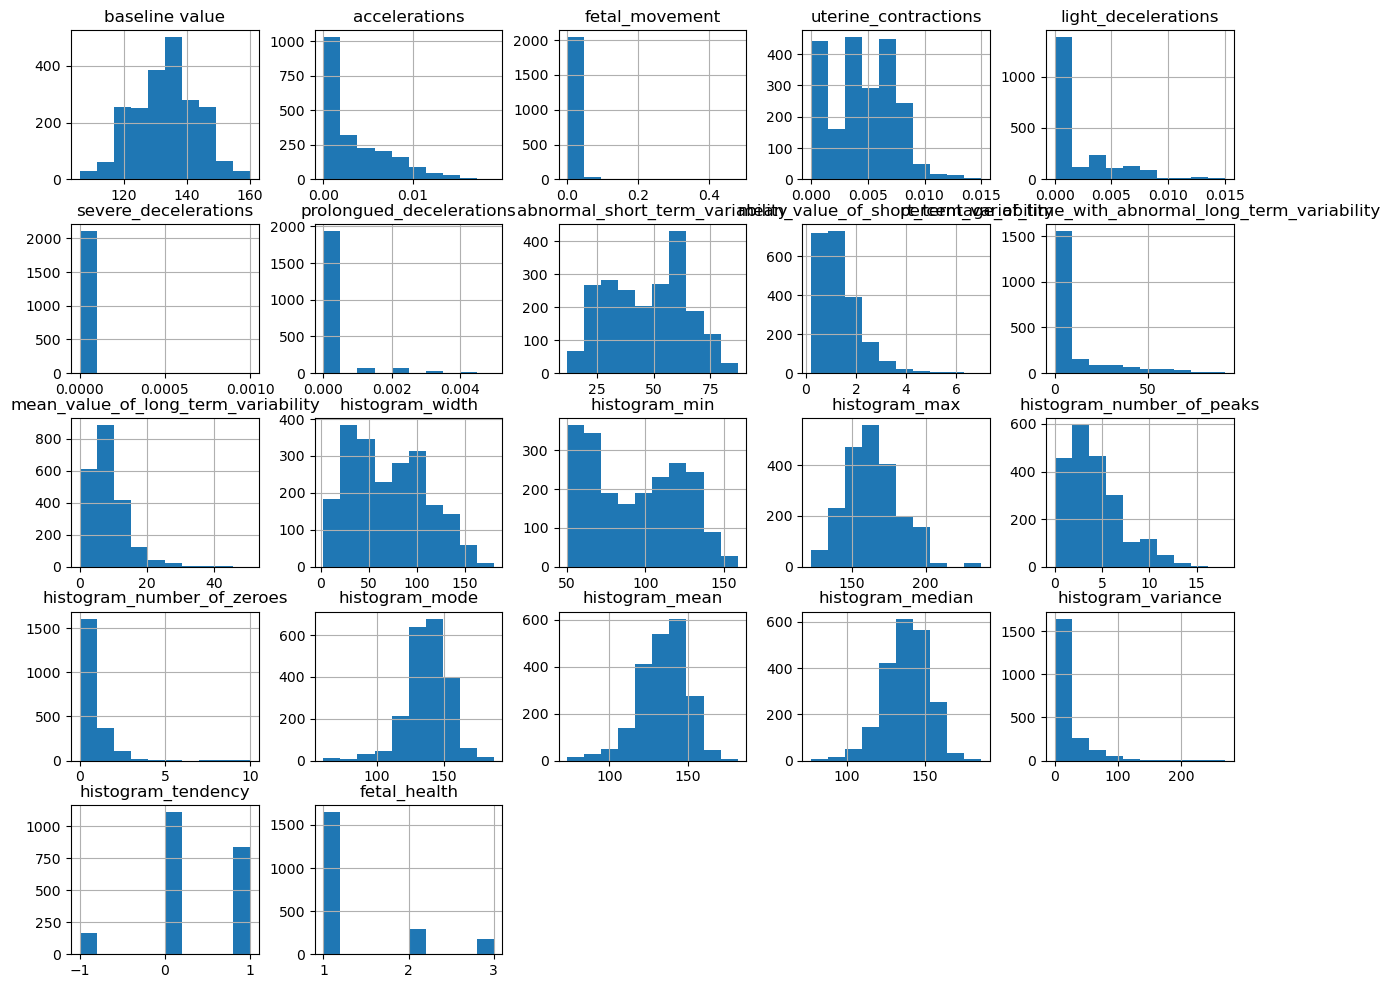

In [16]:
df.hist(figsize=(15,12))
plt.show()

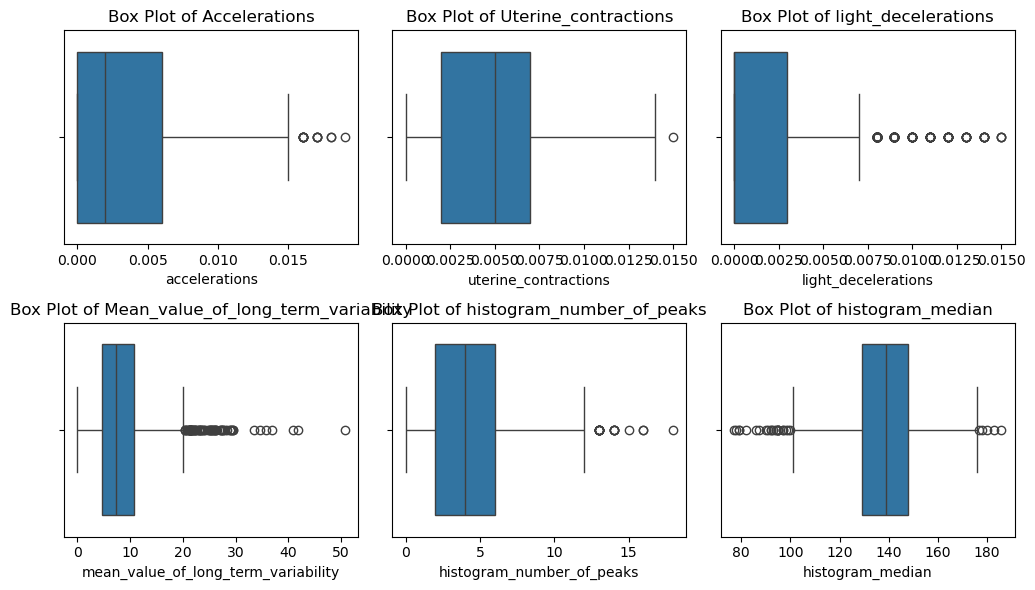

In [17]:
plt.figure(figsize=(10, 6))

# Box plot for 'accelerations'
plt.subplot(2, 3, 1)
sns.boxplot(x='accelerations', data=df)
plt.title("Box Plot of Accelerations")

# Box plot for 'uterine_contractions'
plt.subplot(2, 3, 2)
sns.boxplot(x='uterine_contractions', data=df)
plt.title("Box Plot of Uterine_contractions")

# Box plot for 'light_decelerations'
plt.subplot(2, 3, 3)
sns.boxplot(x='light_decelerations', data=df)
plt.title("Box Plot of light_decelerations")

# Box plot for 'mean_value_of_long_term_variability'
plt.subplot(2, 3, 4)
sns.boxplot(x='mean_value_of_long_term_variability', data=df)
plt.title("Box Plot of Mean_value_of_long_term_variability")

# Box plot for 'histogram_number_of_peaks'
plt.subplot(2, 3, 5)
sns.boxplot(x='histogram_number_of_peaks', data=df)
plt.title("Box Plot of histogram_number_of_peaks")

# Box plot for 'histogram_median'
plt.subplot(2, 3, 6)
sns.boxplot(x='histogram_median', data=df)
plt.title("Box Plot of histogram_median")

plt.tight_layout() # Adjust the spacing between subplots
plt.show()

In [18]:
selected_features = [
    'abnormal_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability',
    'histogram_mean',
    'histogram_median',
    'mean_value_of_short_term_variability',
    'accelerations',
    'histogram_mode',
    'prolongued_decelerations',
    'mean_value_of_long_term_variability',
    'baseline value',
    'fetal_movement'
]

In [19]:
X = df[selected_features]

y = df['fetal_health']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
X_train

,abnormal_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,histogram_mean,histogram_median,mean_value_of_short_term_variability,accelerations,histogram_mode,prolongued_decelerations,mean_value_of_long_term_variability,baseline value,fetal_movement
1583,30,5,130,137,1.8,0.001,139,0.0,19.9,132,0.000
1331,30,0,127,136,1.9,0.008,137,0.0,3.8,128,0.010
2083,73,12,127,130,2.1,0.000,128,0.0,1.4,130,0.009
423,65,0,143,145,0.5,0.000,143,0.0,9.2,143,0.000
633,62,5,154,155,0.5,0.000,153,0.0,6.1,144,0.000
...,...,...,...,...,...,...,...,...,...,...,...
1231,32,4,125,127,0.9,0.000,126,0.0,11.2,126,0.000
44,22,0,113,117,4.4,0.000,119,0.0,15.2,122,0.018
1086,23,1,127,127,1.6,0.000,125,0.0,16.9,122,0.000
1558,22,0,149,152,1.8,0.004,151,0.0,11.5,143,0.000


In [22]:
X_test

,abnormal_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,histogram_mean,histogram_median,mean_value_of_short_term_variability,accelerations,histogram_mode,prolongued_decelerations,mean_value_of_long_term_variability,baseline value,fetal_movement
640,38,0,140,142,1.2,0.000,144,0.0,16.5,138,0.004
1591,20,3,120,127,2.2,0.000,126,0.0,15.1,134,0.000
824,61,74,158,160,0.4,0.000,160,0.0,6.7,152,0.000
1033,25,0,134,136,1.5,0.004,136,0.0,8.9,135,0.000
1097,21,2,125,127,1.8,0.001,126,0.0,14.9,122,0.000
...,...,...,...,...,...,...,...,...,...,...,...
612,39,0,149,150,1.6,0.005,148,0.0,10.0,143,0.013
654,71,77,123,124,0.3,0.000,123,0.0,4.1,123,0.000
284,44,0,136,137,1.1,0.007,137,0.0,7.6,128,0.003
637,44,0,147,148,1.3,0.007,146,0.0,11.4,143,0.018


In [23]:
y_train.shape

(1690,)

In [24]:
y_train.value_counts()

fetal_health
1    1316
2     234
3     140
Name: count, dtype: int64

In [25]:
y_test.value_counts()

fetal_health
1    330
2     58
3     35
Name: count, dtype: int64

In [26]:
y_test.shape

(423,)

In [27]:
y_train

1583    1
1331    1
2083    1
423     2
633     2
       ..
1231    1
44      1
1086    1
1558    1
181     1
Name: fetal_health, Length: 1690, dtype: int64

In [ ]:
Scaling the dataset

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

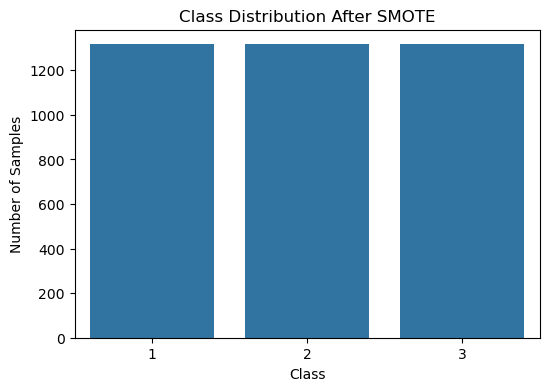

In [32]:
counts = pd.Series(y_train_balanced).value_counts()
plt.figure(figsize=(6,4))
bar = sns.barplot(x=counts.index, y=counts.values)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold

rf= RandomForestClassifier(n_estimators=100,random_state=0, max_depth=6)

k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_train = cross_val_score(rf, X_train_scaled, y_train, cv=k_fold, scoring='accuracy')
average_accuracy_train = cv_scores_train.mean()

rf.fit(X_train_scaled, y_train)

test_accuracy = rf.score(X_test_scaled, y_test)

print('Average accuracy of Random Forest classifier on training set: {:.3f}'.format(average_accuracy_train))
print('Accuracy of Random Forest classifier on test set: {:.3f}'.format(test_accuracy))

Average accuracy of Random Forest classifier on training set: 0.927
Accuracy of Random Forest classifier on test set: 0.931


In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,mean_value_of_short_term_variability,0.187207
0,abnormal_short_term_variability,0.176067
1,percentage_of_time_with_abnormal_long_term_var...,0.146739
2,histogram_mean,0.124988
7,prolongued_decelerations,0.079362
5,accelerations,0.066494
6,histogram_mode,0.065273
3,histogram_median,0.052863
8,mean_value_of_long_term_variability,0.042360
9,baseline value,0.041272


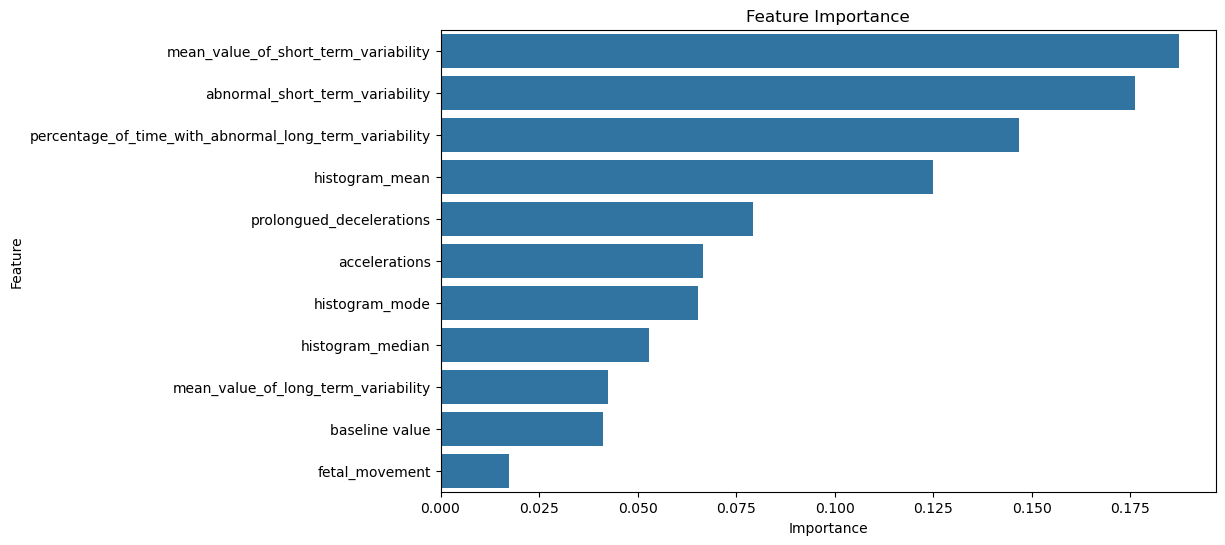

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.sort_values(
        by='Importance',
        ascending=False
    ),
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

lr = LogisticRegression()

k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_train = cross_val_score(lr, X_train_scaled, y_train, cv=k_fold, scoring='accuracy')
average_accuracy_train = cv_scores_train.mean()

lr.fit(X_train_scaled, y_train)

test_accuracy = lr.score(X_test_scaled, y_test)

print('Average accuracy of Logistic Regression on training set: {:.3f}'.format(average_accuracy_train))
print('Accuracy of Logistic Regression on test set: {:.3f}'.format(test_accuracy))

Average accuracy of Logistic Regression on training set: 0.886
Accuracy of Logistic Regression on test set: 0.877


In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_train = cross_val_score(knn, X_train_scaled, y_train, cv=k_fold, scoring='accuracy')
average_accuracy_train = cv_scores_train.mean()

knn.fit(X_train_scaled, y_train)

test_accuracy = knn.score(X_test_scaled, y_test)

print('Average accuracy of KNN on training set: {:.3f}'.format(average_accuracy_train))
print('Accuracy of KNN on test set: {:.3f}'.format(test_accuracy))

Average accuracy of KNN on training set: 0.911
Accuracy of KNN on test set: 0.922


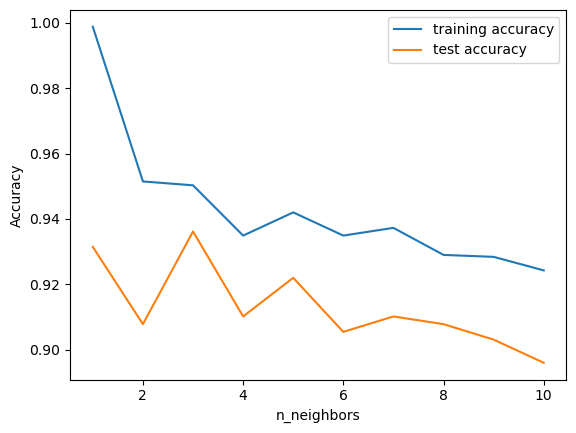

In [38]:
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
 
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
 
    training_accuracy.append(knn.score(X_train_scaled, y_train))
   
    test_accuracy.append(knn.score(X_test_scaled, y_test))

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.savefig('knn_compare_model')

In [39]:
y_pred_knn = knn.predict(X_test_scaled)

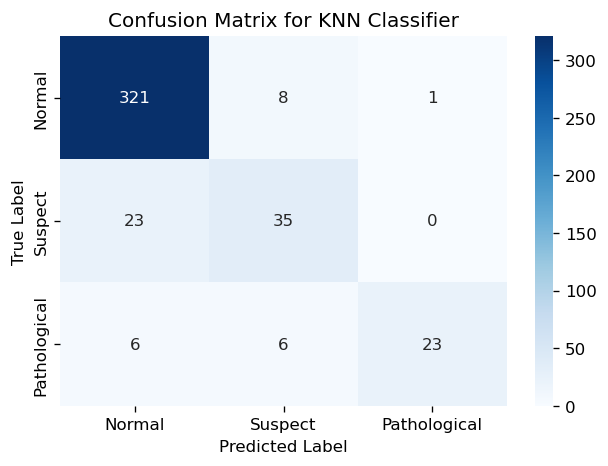

In [40]:
from sklearn.metrics import confusion_matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

labels = ['Normal', 'Suspect', 'Pathological']
cm_df_knn = pd.DataFrame(cm_knn, index=labels, columns=labels)

plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

In [41]:
y_pred_rf = rf.predict(X_test_scaled)

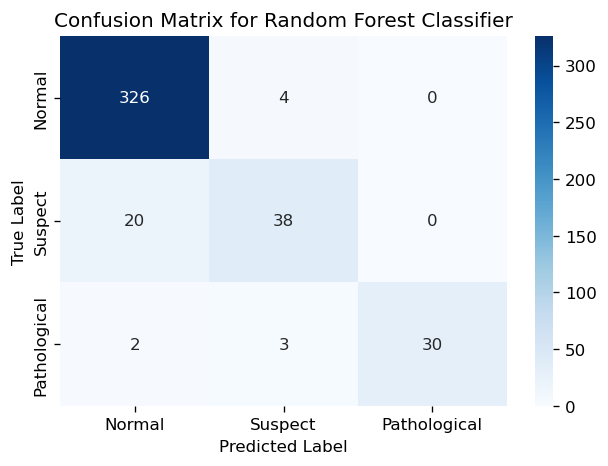

In [42]:
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

labels = ['Normal', 'Suspect', 'Pathological']
cm_df_rf = pd.DataFrame(cm_rf, index=labels, columns=labels)

plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

In [43]:
y_pred_lr = lr.predict(X_test_scaled)

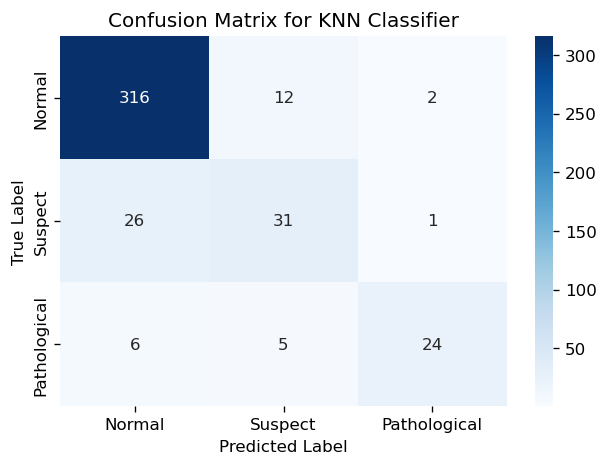

In [44]:
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

labels = ['Normal', 'Suspect', 'Pathological']
cm_df_lr = pd.DataFrame(cm_lr, index=labels, columns=labels)

plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

In [45]:
from sklearn.metrics import accuracy_score
print("ACCURACY SCORE for LR:")
accuracy_score(y_test, y_pred_lr)

ACCURACY SCORE for LR:


0.8770685579196218

In [46]:
from sklearn.metrics import accuracy_score
print("ACCURACY SCORE for KNN:")
accuracy_score(y_test, y_pred_knn)

ACCURACY SCORE for KNN:


0.8959810874704491

In [47]:
from sklearn.metrics import accuracy_score
print("ACCURACY SCORE for rf:")
accuracy_score(y_test, y_pred_rf)

ACCURACY SCORE for rf:


0.9314420803782506

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Random Forest": rf
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred, average='weighted') * 100, 2),
        "Recall": round(recall_score(y_test, y_pred, average='weighted') * 100, 2),
        "F1-Score": round(f1_score(y_test, y_pred, average='weighted') * 100, 2)
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,87.71,87.05,87.71,87.15
1,KNN,89.60,89.27,89.60,89.08
2,Random Forest,93.14,92.94,93.14,92.78


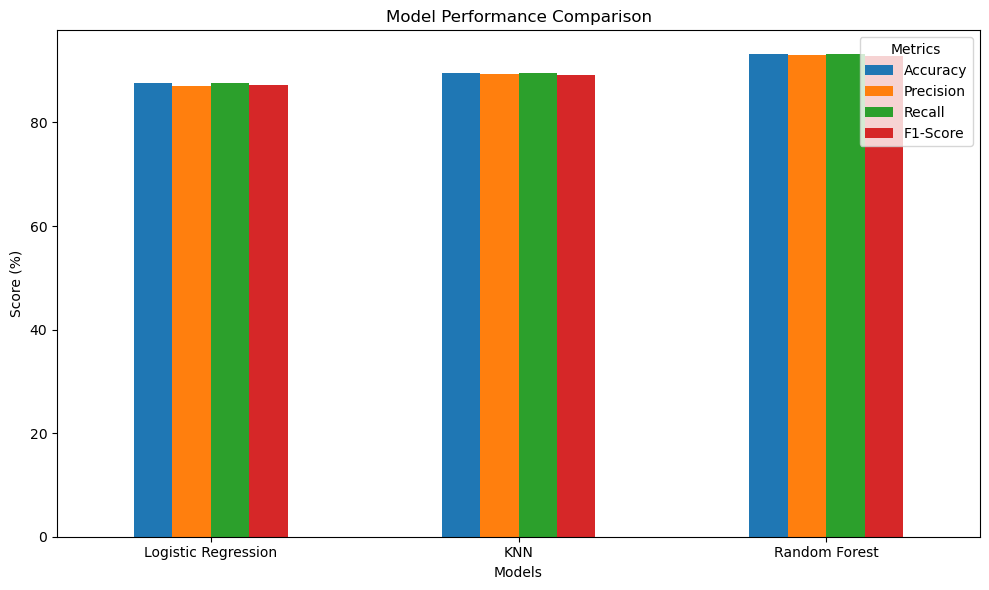

In [49]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xlabel('Models')
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.tight_layout()

plt.show()

In [50]:
from sklearn.metrics import classification_report
print("Classification Report for rf:")
print(classification_report(y_test, y_pred_rf))
print("Classification Report for KNN:")
print(classification_report(y_test, y_pred_knn))
print("Classification Report for lr:")
print(classification_report(y_test, y_pred_lr))

Classification Report for rf:
              precision    recall  f1-score   support

           1       0.94      0.99      0.96       330
           2       0.84      0.66      0.74        58
           3       1.00      0.86      0.92        35

    accuracy                           0.93       423
   macro avg       0.93      0.83      0.87       423
weighted avg       0.93      0.93      0.93       423

Classification Report for KNN:
              precision    recall  f1-score   support

           1       0.92      0.97      0.94       330
           2       0.71      0.60      0.65        58
           3       0.96      0.66      0.78        35

    accuracy                           0.90       423
   macro avg       0.86      0.74      0.79       423
weighted avg       0.89      0.90      0.89       423

Classification Report for lr:
              precision    recall  f1-score   support

           1       0.91      0.96      0.93       330
           2       0.65      0.53     

In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X_train_balanced,
    y_train_balanced,
    cv=5
)

print("Cross-validation Accuracy Scores:", scores)
print(scores.mean())

Cross-validation Accuracy Scores: [0.93037975 0.94810127 0.94683544 0.96197719 0.94803549]
0.9470658259934863


In [52]:
print(scores.std())

0.010028353409061648


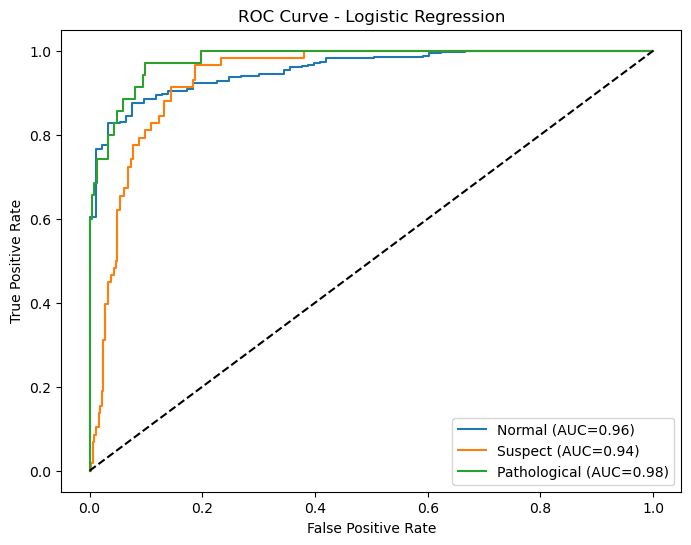

In [53]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_prob_lr = lr.predict_proba(X_test_scaled)

y_test_bin = label_binarize(y_test, classes=[1,2,3])

class_names = ['Normal', 'Suspect', 'Pathological']

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_lr[:,i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} (AUC={roc_auc:.2f})'
    )

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

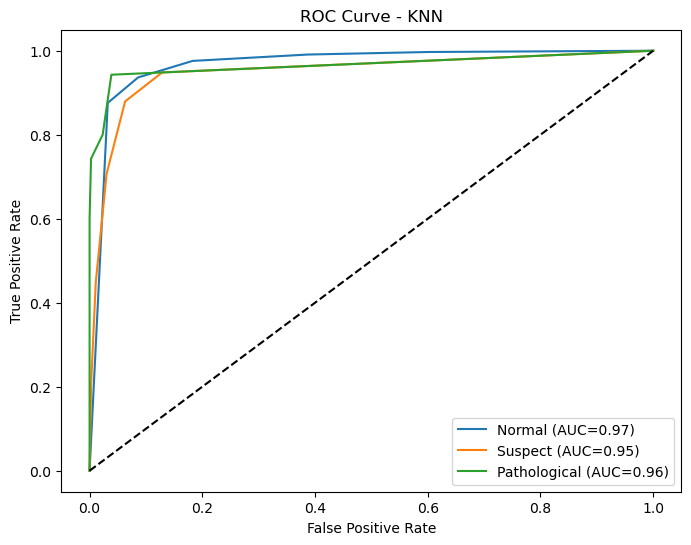

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_prob_knn = knn.predict_proba(X_test_scaled)

y_test_bin = label_binarize(y_test, classes=[1,2,3])

class_names = ['Normal', 'Suspect', 'Pathological']

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} (AUC={roc_auc:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()

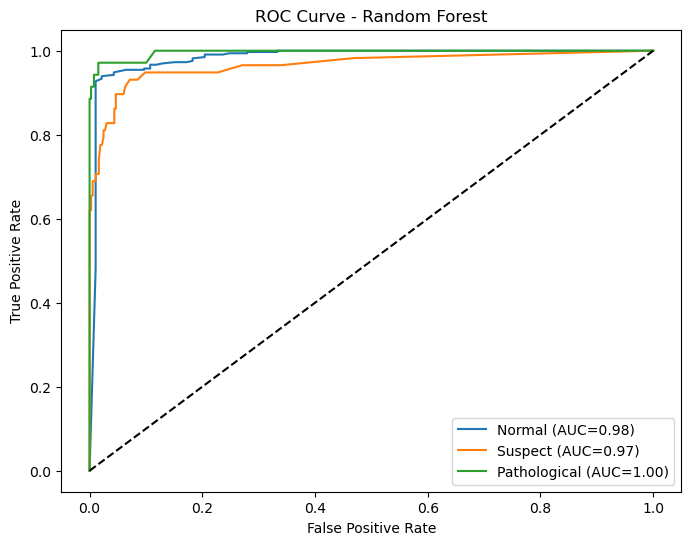

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=[1,2,3])

class_names = ['Normal', 'Suspect', 'Pathological']

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} (AUC={roc_auc:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

In [58]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf.predict_proba(X_test)

roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class='ovr'
)

0.9819363383330016

In [59]:
from sklearn.metrics import roc_auc_score

y_prob_lr = lr.predict_proba(X_test_scaled)

roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class='ovr'
)

0.9566035446174593

In [60]:
from sklearn.metrics import roc_auc_score

y_prob_knn = knn.predict_proba(X_test_scaled)

roc_auc_score(
    y_test,
    y_prob_knn,
    multi_class='ovr'
)

0.9603840021034219

In [61]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [62]:
import joblib

rf_pipeline ={
    "model": rf,
    "scaler": scaler,
    "features" :  X_train.columns.tolist()
}

joblib.dump(rf_pipeline,"rf_fetal_health_model.pkl")

print("Model, scaler and feature list saved successfully!")

Model, scaler and feature list saved successfully!


In [63]:
rf_fetal_health_model = joblib.load("rf_fetal_health_model.pkl")

In [64]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [65]:
pip show joblib

Name: joblib
Version: 1.5.2
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: 
Author-email: Gael Varoquaux <gael.varoquaux@normalesup.org>
License: BSD 3-Clause
Location: C:\Users\PC\anaconda3\Lib\site-packages
Requires: 
Required-by: imbalanced-learn, nltk, scikit-learn
Note: you may need to restart the kernel to use updated packages.
